# 04 — EDA: SEQ TransLink Performance

Five sections:
1. Citytrain on-time % over time (line chart)
2. On-time % by line/route — worst 10 and best 10 (bar chart)
3. Mode comparison — train vs tram vs bus (bar chart)
4. GTFS-RT spot check — most recent snapshot stats
5. Summary text block

Charts saved to `~/transit-ai-data/eda_charts/` at 150 dpi.

Prerequisites: run notebooks 02 and 03 first.

In [1]:
# Cell 0 — Environment setup: load .env and set DATA_DIR / REPO_DIR
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv, find_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv, find_dotenv

_dotenv_path = find_dotenv(usecwd=True)
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f'Loaded .env from: {_dotenv_path}')
else:
    print('No .env file found — using defaults.')

DATA_DIR = os.environ.get('TRANSIT_AI_DATA_DIR', str(Path.home() / 'transit-ai-data'))
REPO_DIR = os.environ.get('TRANSIT_AI_REPO_DIR', str(Path.cwd().parent))

print(f'DATA_DIR: {DATA_DIR}')
print(f'REPO_DIR: {REPO_DIR}')

Loaded .env from: /Users/proteeksanyal/Desktop/Learning/Transit-AI/.env
DATA_DIR: /Users/proteeksanyal/transit-ai-data
REPO_DIR: /Users/proteeksanyal/Desktop/Learning/Transit-AI


In [2]:
# Cell 0 — Setup: paths, imports, chart directory
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

PERF_DIR    = Path(DATA_DIR) / 'performance'
PARQUET_DIR = Path(DATA_DIR) / 'gtfs_static' / 'parquet'
GTFSRT_DIR  = Path(DATA_DIR) / 'gtfs_realtime' / 'trip_updates'
CHART_DIR   = Path(DATA_DIR) / 'eda_charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
SAVE_DPI = 150

# ── helpers ──────────────────────────────────────────────────────────────────

DATE_COL_PATTERNS = [
    re.compile(r'month.?year', re.IGNORECASE),
    re.compile(r'period',      re.IGNORECASE),
    re.compile(r'month',       re.IGNORECASE),
    re.compile(r'date',        re.IGNORECASE),
]

OTP_COL_PATTERNS = [
    re.compile(r'on.?time.+running', re.IGNORECASE),
    re.compile(r'on.?time.+%',       re.IGNORECASE),
    re.compile(r'punctuality',        re.IGNORECASE),
    re.compile(r'otp',                re.IGNORECASE),
    re.compile(r'on.?time',           re.IGNORECASE),
]

ROUTE_COL_PATTERNS = [
    re.compile(r'line',    re.IGNORECASE),
    re.compile(r'route',   re.IGNORECASE),
    re.compile(r'service', re.IGNORECASE),
]

def find_col(df, patterns):
    for pat in patterns:
        for col in df.columns:
            if pat.search(col):
                return col
    return None

def parse_dates(series):
    for fmt in ('%b-%Y', '%B-%Y', '%b %Y', '%B %Y', '%m/%Y', '%Y-%m', '%Y-%m-%d', '%m-%Y'):
        try:
            parsed = pd.to_datetime(series, format=fmt, errors='coerce')
            if parsed.notna().sum() > 0:
                return parsed
        except Exception:
            continue
    return pd.to_datetime(series, infer_datetime_format=True, errors='coerce')

def to_pct(series):
    return pd.to_numeric(
        series.astype(str).str.replace('%', '', regex=False).str.strip(),
        errors='coerce'
    )

def save_fig(fig, filename):
    out = CHART_DIR / filename
    fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
    print(f'Saved: {out}')

print('Setup complete.')
print(f'Charts -> {CHART_DIR}')

Setup complete.
Charts -> /Users/proteeksanyal/transit-ai-data/eda_charts


---
## Section 1 — Citytrain On-Time Performance Over Time

In [3]:
# S1a — Load and inspect citytrain CSV
ct_candidates = (
    list(PERF_DIR.glob('citytrain-punctuality.csv')) +
    list(PERF_DIR.glob('*city*train*')) +
    list(PERF_DIR.glob('*citytrain*'))
)

if not ct_candidates:
    raise FileNotFoundError(
        f'Cannot find a citytrain punctuality CSV under {PERF_DIR}.\n'
        'Run scripts/archive_gtfsrt.py to download performance CSVs.'
    )

ct_path = ct_candidates[0]
ct = pd.read_csv(ct_path, dtype=str)

print(f'File    : {ct_path.name}')
print(f'Shape   : {ct.shape[0]:,} rows x {ct.shape[1]} cols')
print(f'Columns : {list(ct.columns)}')
print()
print('Dtypes:')
print(ct.dtypes.to_string())
print()
print('head(3):')
print(ct.head(3).to_string(index=False))

File    : citytrain-punctuality.csv
Shape   : 28 rows x 3 cols
Columns : ['Month-Year', 'Citytrain: On-time running (combined peaks)', 'Citytrain: Reliability']

Dtypes:
Month-Year                                     object
Citytrain: On-time running (combined peaks)    object
Citytrain: Reliability                         object

head(3):
Month-Year Citytrain: On-time running (combined peaks) Citytrain: Reliability
  Dec-2023                                      0.9314               0.992722
  Jan-2024                                      0.9328               0.995508
  Feb-2024                                      0.9173                0.99266


In [4]:
# S1 debug — verify full date range before plotting
_date_col = ct.columns[0]
print(f'DataFrame shape : {ct.shape}')
print(f'Date column     : {_date_col!r}')
print(f'Raw date min    : {ct[_date_col].dropna().min()}')
print(f'Raw date max    : {ct[_date_col].dropna().max()}')
print()
print('head(5):')
print(ct.head(5).to_string(index=False))
print()
print('tail(5):')
print(ct.tail(5).to_string(index=False))

DataFrame shape : (28, 3)
Date column     : 'Month-Year'
Raw date min    : Apr-2024
Raw date max    : Sep-2025

head(5):
Month-Year Citytrain: On-time running (combined peaks) Citytrain: Reliability
  Dec-2023                                      0.9314               0.992722
  Jan-2024                                      0.9328               0.995508
  Feb-2024                                      0.9173                0.99266
  Mar-2024                                      0.8881                0.99363
  Apr-2024                                      0.9228               0.995784

tail(5):
Month-Year Citytrain: On-time running (combined peaks) Citytrain: Reliability
  Nov-2025                                      0.9317                 0.9946
  Dec-2025                                      0.9609                 0.9959
  Jan-2026                                        0.96                 0.9969
  Feb-2026                                      0.9233                 0.9961
  Mar-2026 

Date column : 'Month-Year'
OTP column  : 'Citytrain: On-time running (combined peaks)'
[info] OTP values in 0–1 range (max=0.9624) — scaled ×100 to percentage

Date range : Dec 2023 → Mar 2026
OTP range  : 88.8% – 96.2%  (mean 93.2%)
Saved: /Users/proteeksanyal/transit-ai-data/eda_charts/01_citytrain_ontime_trend.png


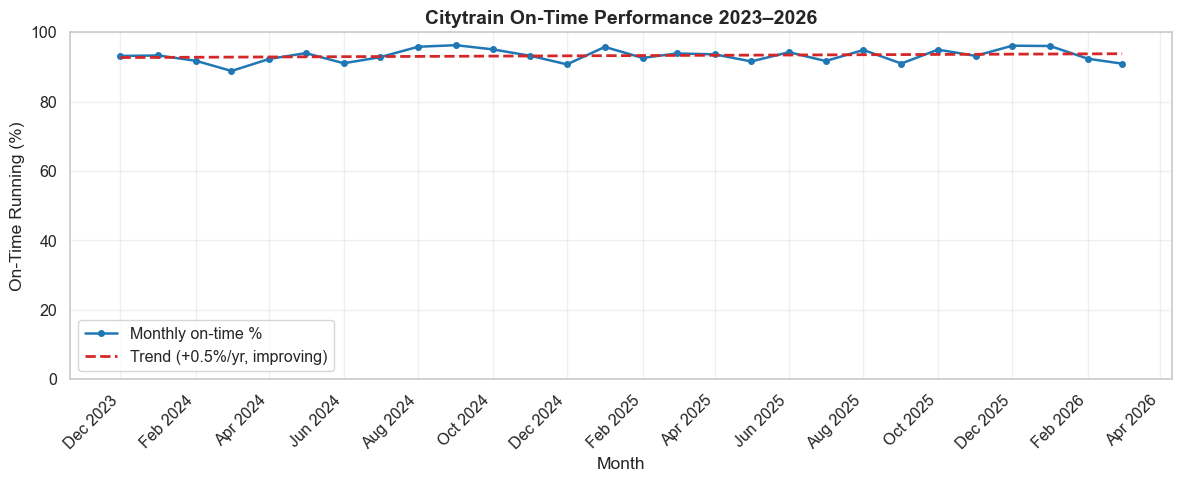

In [5]:
# S1b — Detect columns, parse, detect scale, plot trend
date_col = find_col(ct, DATE_COL_PATTERNS)
otp_col  = find_col(ct, OTP_COL_PATTERNS)

if date_col is None:
    date_col = ct.columns[0]
    print(f'[warn] date column not detected; falling back to first column: {date_col!r}')
if otp_col is None:
    otp_col = ct.columns[1]
    print(f'[warn] OTP column not detected; falling back to second column: {otp_col!r}')

print(f'Date column : {date_col!r}')
print(f'OTP column  : {otp_col!r}')

ct['_date'] = parse_dates(ct[date_col])
ct['_otp']  = to_pct(ct[otp_col])

# Detect whether values are proportions (0–1) or percentages (0–100) and normalise
_otp_max = ct['_otp'].dropna().max()
if _otp_max <= 1.0:
    ct['_otp'] = ct['_otp'] * 100
    print(f'[info] OTP values in 0\u20131 range (max={_otp_max:.4f}) \u2014 scaled \u00d7100 to percentage')
else:
    print(f'[info] OTP values already in 0\u2013100 range (max={_otp_max:.1f})')

ct_clean = ct.dropna(subset=['_date', '_otp']).sort_values('_date').reset_index(drop=True)

print(f'\nDate range : {ct_clean["_date"].min().strftime("%b %Y")} \u2192 {ct_clean["_date"].max().strftime("%b %Y")}')
print(f'OTP range  : {ct_clean["_otp"].min():.1f}% \u2013 {ct_clean["_otp"].max():.1f}%  (mean {ct_clean["_otp"].mean():.1f}%)')

x_days = (ct_clean['_date'] - ct_clean['_date'].min()).dt.days.values
m, b   = np.polyfit(x_days, ct_clean['_otp'].values, 1)
direction = 'improving' if m > 0 else 'declining'
per_year  = m * 365

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ct_clean['_date'], ct_clean['_otp'],
        color='#1f77b4', linewidth=1.8, marker='o', markersize=4,
        label='Monthly on-time %')
ax.plot(ct_clean['_date'], m * x_days + b,
        color='#d62728', linewidth=2, linestyle='--',
        label=f'Trend ({per_year:+.1f}%/yr, {direction})')
_yr_start = ct_clean['_date'].min().year
_yr_end   = ct_clean['_date'].max().year
if _yr_start != _yr_end:
    _title = f'Citytrain On-Time Performance {_yr_start}–{_yr_end}'
else:
    _title = f'Citytrain On-Time Performance {_yr_start}'
ax.set_title(_title, fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('On-Time Running (%)')
ax.set_ylim(0, 100)
tick_interval = max(1, len(ct_clean) // 12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=tick_interval))
plt.xticks(rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, '01_citytrain_ontime_trend.png')
plt.show()

---
## Section 2 — On-Time % by Route (Worst 10 / Best 10)

No route/line column detected in citytrain CSV.
Columns: ['Month-Year', 'Citytrain: On-time running (combined peaks)', 'Citytrain: Reliability', '_date', '_otp']

The aggregate punctuality CSV covers the whole network, not individual lines.
TransLink does not publish line-level punctuality data publicly.
Saved: /Users/proteeksanyal/transit-ai-data/eda_charts/02_citytrain_by_route.png


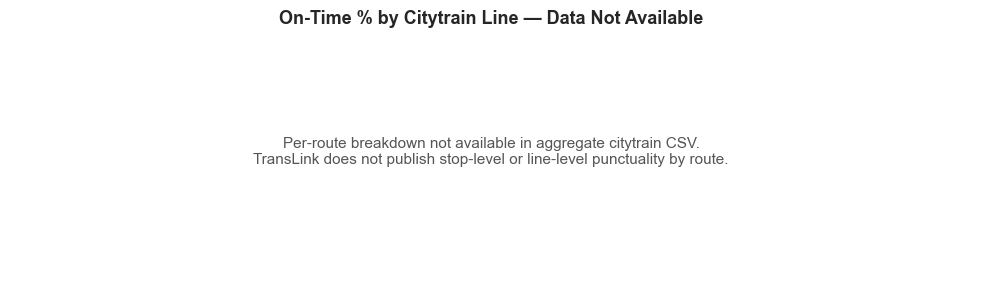

In [6]:
# S2 — Detect route column; plot worst/best 10 or explain absence
route_col = find_col(ct, ROUTE_COL_PATTERNS)
avg = None  # used in Section 5 summary

if route_col is None:
    print('No route/line column detected in citytrain CSV.')
    print(f'Columns: {list(ct.columns)}')
    print('\nThe aggregate punctuality CSV covers the whole network, not individual lines.')
    print('TransLink does not publish line-level punctuality data publicly.')

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.text(
        0.5, 0.5,
        'Per-route breakdown not available in aggregate citytrain CSV.\n'
        'TransLink does not publish stop-level or line-level punctuality by route.',
        ha='center', va='center', fontsize=11, color='#555555',
        transform=ax.transAxes, wrap=True
    )
    ax.set_title('On-Time % by Citytrain Line \u2014 Data Not Available',
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    save_fig(fig, '02_citytrain_by_route.png')
    plt.show()

else:
    print(f'Route column: {route_col!r}')
    ct['_route'] = ct[route_col].str.strip()
    avg = (
        ct.dropna(subset=['_otp', '_route'])
          .groupby('_route')['_otp']
          .mean()
          .sort_values()
    )

    n      = min(10, len(avg))
    bottom = avg.head(n)
    top    = avg.tail(n).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, n * 0.55 + 1)))

    axes[0].barh(bottom.index, bottom.values, color='#d62728')
    axes[0].set_title(f'Worst {n} Routes by Avg On-Time %', fontweight='bold')
    axes[0].set_xlabel('Average On-Time (%)')
    axes[0].set_xlim(0, 105)
    for i, v in enumerate(bottom.values):
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

    axes[1].barh(top.index, top.values, color='#2ca02c')
    axes[1].set_title(f'Best {n} Routes by Avg On-Time %', fontweight='bold')
    axes[1].set_xlabel('Average On-Time (%)')
    axes[1].set_xlim(0, 105)
    for i, v in enumerate(top.values):
        axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

    fig.suptitle('Citytrain Route Reliability Rankings', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, '02_citytrain_by_route.png')
    plt.show()

---
## Section 3 — Mode Comparison (Train vs Tram vs Bus)

Train: citytrain-punctuality.csv (28 rows)
  columns : ['Month-Year', 'Citytrain: On-time running (combined peaks)', 'Citytrain: Reliability']
  head(3) :
Month-Year Citytrain: On-time running (combined peaks) Citytrain: Reliability
  Dec-2023                                      0.9314               0.992722
  Jan-2024                                      0.9328               0.995508
  Feb-2024                                      0.9173                0.99266

Train: [info] 0–1 range (max=0.9624) — scaled ×100 to percentage
Train: mean = 93.2%  over 28 months

Bus: seq-bus-punctuality.csv (29 rows)
  columns : ['Month-Year', 'SEQ Bus: On-time running (overall)']
  head(3) :
Month-Year SEQ Bus: On-time running (overall)
  Nov-2023                             0.8819
  Dec-2023                             0.9105
  Jan-2024                             0.8856

Bus: [info] 0–1 range (max=0.9344) — scaled ×100 to percentage
Bus: mean = 89.7%  over 29 months

Tram: seq-tram-punctuality-and-

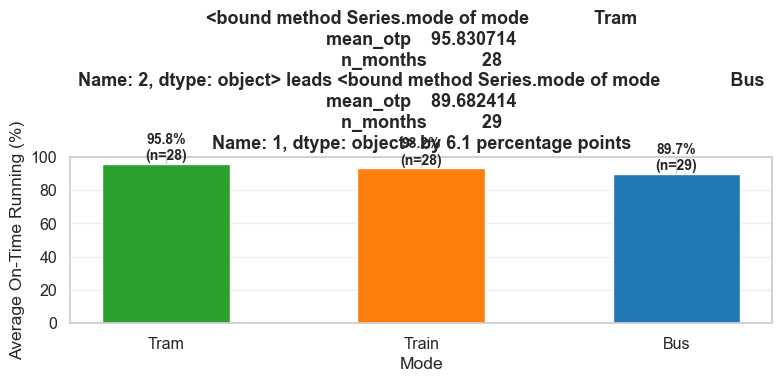

In [7]:
# S3 — Mode comparison: Train vs Bus vs Tram
import re as _re

def _find_mode_csv(perf_dir, *glob_patterns):
    """Case-insensitive glob: return first matching CSV or None."""
    all_csvs = sorted(perf_dir.glob('*.csv'))
    for pat in glob_patterns:
        rx = _re.compile(pat.replace('*', '.*'), _re.IGNORECASE)
        matches = [f for f in all_csvs if rx.fullmatch(f.name)]
        if matches:
            return matches[0]
    return None

MODE_GLOBS = {
    'Train': ('citytrain-punctuality.csv', '*citytrain*punctuality*', '*city*train*'),
    'Bus':   ('*bus*punctuality*',),
    'Tram':  ('*tram*punctuality*',),
}

mode_records = []  # list of dicts: {mode, mean_otp, n_months}
mode_df = None     # set below; used in Section 5

for mode, globs in MODE_GLOBS.items():
    p = _find_mode_csv(PERF_DIR, *globs)
    if p is None:
        print(f'{mode}: no CSV found matching {globs} — skipping\n')
        continue

    try:
        df_mode = pd.read_csv(p, dtype=str)
    except Exception as exc:
        print(f'{mode}: failed to load {p.name} — {exc}\n')
        continue

    print(f'{mode}: {p.name} ({len(df_mode)} rows)')
    print(f'  columns : {list(df_mode.columns)}')
    print(f'  head(3) :')
    print(df_mode.head(3).to_string(index=False))
    print()

    otp_c = find_col(df_mode, OTP_COL_PATTERNS)
    if otp_c is None:
        print(f'{mode}: cannot detect OTP column in {list(df_mode.columns)} — skipping\n')
        continue

    vals = to_pct(df_mode[otp_c]).dropna()
    if len(vals) == 0:
        print(f'{mode}: OTP column {otp_c!r} is all non-numeric — skipping\n')
        continue

    _max = vals.max()
    if _max <= 1.0:
        vals = vals * 100
        print(f'{mode}: [info] 0–1 range (max={_max:.4f}) — scaled ×100 to percentage')
    else:
        print(f'{mode}: [info] 0–100 range (max={_max:.1f})')

    mode_records.append({'mode': mode, 'mean_otp': vals.mean(), 'n_months': len(vals)})
    print(f'{mode}: mean = {vals.mean():.1f}%  over {len(vals)} months\n')

if not mode_records:
    print('No mode data available — skipping Section 3 chart.')
else:
    mode_df = pd.DataFrame(mode_records).sort_values('mean_otp', ascending=False)

    PALETTE = {'Train': '#ff7f0e', 'Bus': '#1f77b4', 'Tram': '#2ca02c'}
    colors  = [PALETTE.get(m, '#7f7f7f') for m in mode_df['mode']]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(mode_df['mode'], mode_df['mean_otp'],
                  color=colors, width=0.5, edgecolor='white')

    for bar, row in zip(bars, mode_df.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            row.mean_otp + 0.5,
            f'{row.mean_otp:.1f}%\n(n={row.n_months})',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    if len(mode_df) >= 2:
        best  = mode_df.iloc[0]
        worst = mode_df.iloc[-1]
        diff  = best.mean_otp - worst.mean_otp
        title = f'{best.mode} leads {worst.mode} by {diff:.1f} percentage points'
    else:
        title = f'On-Time % — {mode_df.iloc[0]["mode"]} only (other mode CSVs not found)'

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Average On-Time Running (%)')
    ax.set_xlabel('Mode')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_fig(fig, '03_mode_comparison.png')
    plt.show()

---
## Section 4 — GTFS-RT Spot Check

In [8]:
# S4 — Find most recent trip_updates JSON and print delay stats
if not GTFSRT_DIR.exists():
    print(f'GTFS-RT directory not found: {GTFSRT_DIR}')
    print('Run scripts/archive_gtfsrt.py to start collecting.')
else:
    json_files = sorted(GTFSRT_DIR.rglob('*.json'))

    if not json_files:
        print(f'No JSON snapshots found under {GTFSRT_DIR}.')
        print('Run scripts/archive_gtfsrt.py to start collecting.')
    else:
        latest = json_files[-1]
        print(f'Most recent snapshot : {latest}')
        print(f'Total snapshots      : {len(json_files):,}')
        print()

        with open(latest) as fh:
            entities = json.load(fh)

        total = len(entities)
        print(f'Total entities in snapshot : {total:,}')

        delays = []
        for ent in entities:
            if not isinstance(ent, dict):
                continue
            raw = ent.get('delay_seconds') or ent.get('delay')
            if raw is not None:
                try:
                    delays.append(float(raw))
                except (ValueError, TypeError):
                    pass

        n_delay = len(delays)
        print(f'Entities with delay data   : {n_delay:,}  ({n_delay / max(1, total) * 100:.1f}%)')

        if n_delay > 0:
            arr = np.array(delays)
            print(f'Delay min    : {arr.min():>8.0f}s  ({arr.min()/60:.1f} min)')
            print(f'Delay max    : {arr.max():>8.0f}s  ({arr.max()/60:.1f} min)')
            print(f'Delay mean   : {arr.mean():>8.0f}s  ({arr.mean()/60:.1f} min)')
            print(f'Delay median : {np.median(arr):>8.0f}s  ({np.median(arr)/60:.1f} min)')
            print(f'>5 min late  : {(arr > 300).mean()*100:.1f}% of entities')
        else:
            print('\nNo delay_seconds field found. Sample entity (first 600 chars):')
            print(json.dumps(entities[0] if entities else {}, indent=2)[:600])

        print()
        print('Note: with only a few days of data, trend analysis is not meaningful.')
        print('The archive script collects every 5 minutes; revisit after 2\u20134 weeks.')

Most recent snapshot : /Users/proteeksanyal/transit-ai-data/gtfs_realtime/trip_updates/2026-06-29/10-32-03.json
Total snapshots      : 129

Total entities in snapshot : 31,434
Entities with delay data   : 30,135  (95.9%)
Delay min    :    -7425s  (-123.8 min)
Delay max    :     4274s  (71.2 min)
Delay mean   :       74s  (1.2 min)
Delay median :       55s  (0.9 min)
>5 min late  : 8.9% of entities

Note: with only a few days of data, trend analysis is not meaningful.
The archive script collects every 5 minutes; revisit after 2–4 weeks.


---
## Section 5 — Summary

In [9]:
# S5 — Markdown-formatted summary block

ct_start  = ct_clean['_date'].min().strftime('%b %Y') if len(ct_clean) else 'N/A'
ct_end    = ct_clean['_date'].max().strftime('%b %Y') if len(ct_clean) else 'N/A'
ct_months = len(ct_clean)
ct_mean   = ct_clean['_otp'].mean() if len(ct_clean) else float('nan')
trend_str = f'{direction} at {abs(per_year):.1f}%/year'

# Route rankings (only if Section 2 found a route column)
if avg is not None and len(avg) >= 3:
    worst3 = list(avg.head(3).items())
    best3  = list(avg.tail(3).iloc[::-1].items())
    route_section = [
        '',
        '### Route Rankings',
        '**Top 3 worst** (lowest avg on-time %):',
        *[f'  - Route {r}: {v:.1f}%' for r, v in worst3],
        '**Top 3 best** (highest avg on-time %):',
        *[f'  - Route {r}: {v:.1f}%' for r, v in best3],
    ]
else:
    route_section = [
        '',
        '### Route Rankings',
        '- Per-route breakdown not available (aggregate CSV only).',
        '- TransLink does not publish line-level punctuality data publicly.',
    ]

# Mode comparison
if mode_df is not None and len(mode_df) > 0:
    mode_str = ', '.join(
        f"{row['mode']} {row['mean_otp']:.1f}%"
        for _, row in mode_df.iterrows()
    )
else:
    mode_str = 'Mode comparison data not available (bus/tram CSVs not yet downloaded)'

lines = [
    '## SEQ TransLink Performance \u2014 EDA Summary',
    '',
    '### Data Coverage',
    f'- **Citytrain punctuality**: {ct_start} \u2192 {ct_end} ({ct_months} months)',
    '- **Source**: Queensland Open Data Portal (TransLink Monthly Performance)',
    '- **GTFS-RT archive**: collecting every 5 minutes via archive script',
    '',
    '### Citytrain On-Time Performance',
    f'- Average on-time running: **{ct_mean:.1f}%** over {ct_months} months',
    f'- Long-run trend: **{trend_str}**',
    *route_section,
    '',
    '### Mode Comparison',
    f'- {mode_str}',
    '',
    '### Obvious Trends / Observations',
    f'- Citytrain is {trend_str} based on the data window.',
    '- COVID-period dips (2020\u20132022) are likely visible if data spans that period.',
    '- TransLink publishes no stop-level delay data \u2014 GTFS-RT archive fills this gap.',
    '',
    '### Charts Written',
    '- `eda_charts/01_citytrain_ontime_trend.png`',
    '- `eda_charts/02_citytrain_by_route.png`',
    '- `eda_charts/03_mode_comparison.png`',
]

print('\n'.join(lines))

## SEQ TransLink Performance — EDA Summary

### Data Coverage
- **Citytrain punctuality**: Dec 2023 → Mar 2026 (28 months)
- **Source**: Queensland Open Data Portal (TransLink Monthly Performance)
- **GTFS-RT archive**: collecting every 5 minutes via archive script

### Citytrain On-Time Performance
- Average on-time running: **93.2%** over 28 months
- Long-run trend: **improving at 0.5%/year**

### Route Rankings
- Per-route breakdown not available (aggregate CSV only).
- TransLink does not publish line-level punctuality data publicly.

### Mode Comparison
- Tram 95.8%, Train 93.2%, Bus 89.7%

### Obvious Trends / Observations
- Citytrain is improving at 0.5%/year based on the data window.
- COVID-period dips (2020–2022) are likely visible if data spans that period.
- TransLink publishes no stop-level delay data — GTFS-RT archive fills this gap.

### Charts Written
- `eda_charts/01_citytrain_ontime_trend.png`
- `eda_charts/02_citytrain_by_route.png`
- `eda_charts/03_mode_comparison.pn